In [6]:
import json
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

DATA_DIR  = ROOT / "data" / "raw"
EVAL_FILE = ROOT / "eval" / "golden_dataset" / "docs" / "eval_v1.jsonl"



def load_docs(data_dir: Path) -> list[dict]:
    docs = []
    for path in sorted(data_dir.rglob("*.md")) + sorted(data_dir.rglob("*.mdx")):
        text = path.read_text(encoding="utf-8")
        if len(text.strip()) < 100:
            continue
        docs.append({"source": str(path.relative_to(data_dir)), "text": text})
    print(f"Loaded {len(docs)} documents")
    return docs

docs = load_docs(DATA_DIR)



eval_set = [json.loads(l) for l in EVAL_FILE.read_text().splitlines() if l.strip()]
print(f"Loaded {len(eval_set)} Q&A pairs from eval set")

Loaded 9 documents
Loaded 78 Q&A pairs from eval set


In [10]:
import sys, os
from pathlib import Path

ROOT = Path("..").resolve()

sys.path.insert(0, str(ROOT))


from backend.connectors.chunkers.heading_aware_chunker import HeadingAwareChunker
from backend.connectors.chunkers.sliding_window_chunker import SlidingWindowChunker

def build_corpus(docs: list[dict], chunker, label: str) -> list[dict]:
    """Chunk all docs and return flat list of {id, text, source, label}."""
    corpus = []
    chunk_id = 0

    for doc in docs:
        chunks = chunker.chunk(
            doc["text"],
            metadata={
            "tenant_id": "eval",
            "source_type": "docs_site",
            "source_url": doc["source"],
            }
            )

        for c in chunks:
            corpus.append({
                "id": chunk_id,
                "text": c.content,
                "source": doc["source"],
                "label": label,
            })
            chunk_id += 1
    return corpus

# Build all 4 corpora
corpora = {
    "HAC":       build_corpus(docs, HeadingAwareChunker(), "HAC"),
    "SW-128":    build_corpus(docs, SlidingWindowChunker(window_tokens=128, overlap_tokens=20), "SW-128"),
    "SW-256":    build_corpus(docs, SlidingWindowChunker(window_tokens=256, overlap_tokens=40), "SW-256"),
    "SW-512":    build_corpus(docs, SlidingWindowChunker(window_tokens=512, overlap_tokens=80), "SW-512"),
}

for name, corpus in corpora.items():
    avg_len = sum(len(c["text"]) for c in corpus) // len(corpus)
    print(f"  {name:8s}: {len(corpus):3d} chunks, avg {avg_len} chars/chunk")

  HAC     : 127 chunks, avg 929 chars/chunk
  SW-128  : 259 chunks, avg 538 chars/chunk
  SW-256  : 133 chunks, avg 1047 chars/chunk
  SW-512  :  69 chunks, avg 2005 chars/chunk


In [11]:
from rank_bm25 import BM25Okapi

def build_bm25_index(corpus: list[dict]) -> BM25Okapi:
    tokenized = [c["text"].lower().split() for c in corpus]
    return BM25Okapi(tokenized)

def bm25_retrieve(index: BM25Okapi, corpus: list[dict], query: str, top_k: int = 5) -> list[dict]:
    scores = index.get_scores(query.lower().split())
    ranked = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [corpus[i] for i in ranked]

In [12]:
import numpy as np
from tqdm import tqdm

def embed_texts(texts: list[str], batch_size: int = 100) -> np.ndarray:
    """Embed a list of texts in batches. Returns (N, 1536) numpy array."""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[i:i+batch_size]
        resp = client.embeddings.create(model="text-embedding-3-small", input=batch)
        vecs = [e.embedding for e in sorted(resp.data, key=lambda x: x.index)]
        all_embeddings.extend(vecs)
    return np.array(all_embeddings, dtype=np.float32)

def cosine_sim(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Dot product of L2-normalised vectors = cosine similarity."""
    a_norm = a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-9)
    b_norm = b / (np.linalg.norm(b, axis=-1, keepdims=True) + 1e-9)
    return a_norm @ b_norm.T   # (N_queries, N_corpus)

def dense_retrieve(query_vec: np.ndarray, corpus_vecs: np.ndarray,
                   corpus: list[dict], top_k: int = 5) -> list[dict]:
    sims = cosine_sim(query_vec.reshape(1, -1), corpus_vecs)[0]
    ranked = np.argsort(sims)[::-1][:top_k]
    return [corpus[i] for i in ranked]

In [14]:
from openai import OpenAI
client = OpenAI()

EMBED_CACHE_DIR = ROOT / "eval" / "embed_cache"
EMBED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def get_corpus_embeddings(corpus: list[dict], name: str) -> np.ndarray:
    """Load from cache or compute embeddings for a corpus."""
    cache_path = EMBED_CACHE_DIR / f"{name}_corpus.npy"
    if cache_path.exists():
        print(f"  Loading {name} embeddings from cache")
        return np.load(cache_path)
    print(f"  Computing {name} embeddings ({len(corpus)} chunks)...")
    vecs = embed_texts([c["text"] for c in corpus])
    np.save(cache_path, vecs)
    return vecs

def get_query_embeddings(queries: list[str]) -> np.ndarray:
    """Load from cache or compute query embeddings."""
    cache_path = EMBED_CACHE_DIR / "queries.npy"
    if cache_path.exists():
        print("  Loading query embeddings from cache")
        return np.load(cache_path)
    print(f"  Computing {len(queries)} query embeddings...")
    vecs = embed_texts(queries)
    np.save(cache_path, vecs)
    return vecs

queries = [qa["question"] for qa in eval_set]
query_vecs = get_query_embeddings(queries)

corpus_vecs = {}
for name, corpus in corpora.items():
    corpus_vecs[name] = get_corpus_embeddings(corpus, name)

print("All embeddings ready.")

  Computing 78 query embeddings...


Embedding: 100%|██████████| 1/1 [00:03<00:00,  3.37s/it]


  Computing HAC embeddings (127 chunks)...


Embedding: 100%|██████████| 2/2 [00:03<00:00,  1.71s/it]


  Computing SW-128 embeddings (259 chunks)...


...

  Computing SW-256 embeddings (133 chunks)...


Embedding: 100%|██████████| 2/2 [00:01<00:00,  1.39it/s]


  Computing SW-512 embeddings (69 chunks)...


Embedding: 100%|██████████| 1/1 [00:00<00:00,  2.34it/s]

All embeddings ready.


In [15]:
def rrf_fusion(bm25_results: list[dict], dense_results: list[dict],
               k: int = 60) -> list[dict]:
    """
    Reciprocal Rank Fusion (RRF) — same formula Qdrant uses internally.
    score(doc) = Σ 1 / (k + rank_in_list)
    """
    scores: dict[int, float] = {}
    for rank, chunk in enumerate(bm25_results, start=1):
        scores[chunk["id"]] = scores.get(chunk["id"], 0) + 1 / (k + rank)
    for rank, chunk in enumerate(dense_results, start=1):
        scores[chunk["id"]] = scores.get(chunk["id"], 0) + 1 / (k + rank)
    
    # Map id back to chunk dict
    id_to_chunk = {c["id"]: c for c in bm25_results + dense_results}
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [id_to_chunk[cid] for cid, _ in ranked]




In [16]:
def is_relevant(retrieved_chunk: dict, qa: dict, threshold: int = 40) -> bool:
    """
    A chunk is relevant if it contains the source_text anchor from the Q&A pair.
    We use a 40-char substring match — robust to minor whitespace differences.
    """
    anchor = qa.get("source_text", "")[:threshold].lower().strip()
    if not anchor:
        # Fallback: check if chunk source file matches and answer appears
        return (qa["source"] in retrieved_chunk["source"] and 
                qa["answer"][:30].lower() in retrieved_chunk["text"].lower())
    return anchor in retrieved_chunk["text"].lower()



In [17]:
def evaluate(corpus: list[dict], corpus_vecs: np.ndarray,
             bm25_index: BM25Okapi, eval_set: list[dict],
             query_vecs: np.ndarray, top_k: int = 5) -> dict:
    """
    Returns dict with Recall@K, Precision@K, MRR for BM25 / Dense / Hybrid.
    """
    results = {
        "bm25":   {"recall": [], "precision": [], "mrr": []},
        "dense":  {"recall": [], "precision": [], "mrr": []},
        "hybrid": {"recall": [], "precision": [], "mrr": []},
    }
    
    for i, qa in enumerate(eval_set):
        q_vec = query_vecs[i]
        
        bm25_hits   = bm25_retrieve(bm25_index, corpus, qa["question"], top_k=top_k)
        dense_hits  = dense_retrieve(q_vec, corpus_vecs, corpus, top_k=top_k)
        hybrid_hits = rrf_fusion(bm25_hits, dense_hits)[:top_k]
        
        for method, hits in [("bm25", bm25_hits), ("dense", dense_hits), ("hybrid", hybrid_hits)]:
            relevances = [is_relevant(h, qa) for h in hits]
            
            # Recall@K: did we find at least one relevant chunk?
            results[method]["recall"].append(int(any(relevances)))
            
            # Precision@K: fraction of retrieved that are relevant
            results[method]["precision"].append(sum(relevances) / top_k)
            
            # MRR: 1/rank of first relevant hit (0 if none found)
            mrr = 0.0
            for rank, rel in enumerate(relevances, start=1):
                if rel:
                    mrr = 1 / rank
                    break
            results[method]["mrr"].append(mrr)
    
    summary = {}
    for method in results:
        summary[method] = {
            f"Recall@{top_k}":    round(sum(results[method]["recall"])    / len(eval_set), 3),
            f"Precision@{top_k}": round(sum(results[method]["precision"]) / len(eval_set), 3),
            "MRR":                round(sum(results[method]["mrr"])        / len(eval_set), 3),
        }
    return summary

In [18]:
import pandas as pd

all_results = []

for chunker_name, corpus in corpora.items():
    print(f"\nEvaluating {chunker_name} ({len(corpus)} chunks)...")
    bm25_idx = build_bm25_index(corpus)
    c_vecs = corpus_vecs[chunker_name]
    
    scores = evaluate(corpus, c_vecs, bm25_idx, eval_set, query_vecs, top_k=5)
    
    for method, metrics in scores.items():
        all_results.append({
            "Chunker": chunker_name,
            "Retrieval": method,
            **metrics
        })

df = pd.DataFrame(all_results)
df = df.sort_values(["Recall@5", "MRR"], ascending=False)
print("\n", df.to_string(index=False))


Evaluating HAC (127 chunks)...

Evaluating SW-128 (259 chunks)...

Evaluating SW-256 (133 chunks)...

Evaluating SW-512 (69 chunks)...

 Chunker Retrieval  Recall@5  Precision@5   MRR
    HAC    hybrid     0.821        0.169 0.698
 SW-128     dense     0.821        0.187 0.687
 SW-128    hybrid     0.821        0.185 0.669
    HAC     dense     0.808        0.172 0.755
 SW-512    hybrid     0.808        0.177 0.688
 SW-256    hybrid     0.808        0.179 0.658
 SW-256     dense     0.808        0.179 0.656
 SW-512     dense     0.795        0.177 0.707
 SW-256      bm25     0.744        0.164 0.570
 SW-512      bm25     0.731        0.156 0.586
    HAC      bm25     0.705        0.146 0.593
 SW-128      bm25     0.679        0.156 0.552


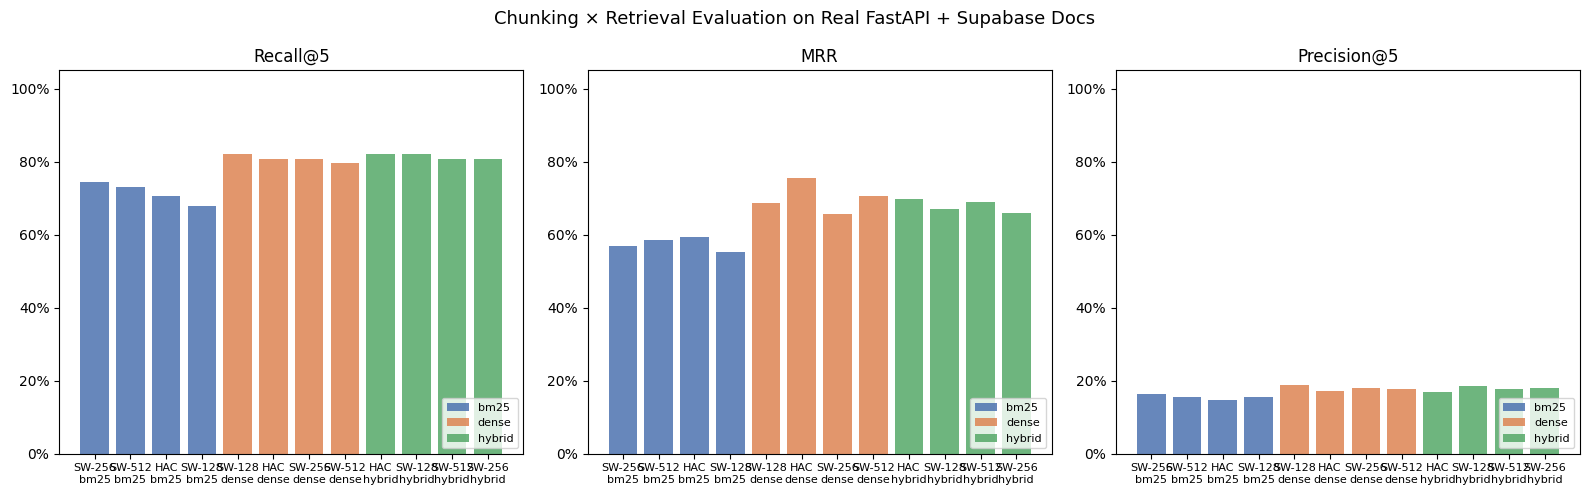

Saved chart to eval/golden_dataset/results_v1.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

metrics_to_plot = ["Recall@5", "MRR", "Precision@5"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chunking × Retrieval Evaluation on Real FastAPI + Supabase Docs", fontsize=13)

colors = {"bm25": "#4C72B0", "dense": "#DD8452", "hybrid": "#55A868"}

for ax, metric in zip(axes, metrics_to_plot):
    for method in ["bm25", "dense", "hybrid"]:
        subset = df[df["Retrieval"] == method]
        ax.bar(
            [f"{r}\n{method}" for r in subset["Chunker"]],
            subset[metric],
            color=colors[method],
            label=method,
            alpha=0.85,
        )
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "eval" / "golden_dataset" / "results_v1.png", dpi=150)
plt.show()
print("Saved chart to eval/golden_dataset/results_v1.png")

In [20]:
def show_failures(corpus: list[dict], corpus_vecs: np.ndarray,
                  bm25_index, eval_set: list[dict],
                  query_vecs: np.ndarray, method: str = "bm25",
                  top_k: int = 5, max_show: int = 3):
    """Print Q&A pairs where the retrieval method failed to find the answer."""
    failures = []
    for i, qa in enumerate(eval_set):
        if method == "bm25":
            hits = bm25_retrieve(bm25_index, corpus, qa["question"], top_k)
        elif method == "dense":
            hits = dense_retrieve(query_vecs[i], corpus_vecs, corpus, top_k)
        else:
            b = bm25_retrieve(bm25_index, corpus, qa["question"], top_k)
            d = dense_retrieve(query_vecs[i], corpus_vecs, corpus, top_k)
            hits = rrf_fusion(b, d)[:top_k]
        
        if not any(is_relevant(h, qa) for h in hits):
            failures.append((qa, hits))
    
    print(f"\n{method.upper()} failures: {len(failures)} / {len(eval_set)}")
    for qa, hits in failures[:max_show]:
        print(f"\n  Q: {qa['question']}")
        print(f"  Expected source_text: {qa.get('source_text', 'N/A')[:80]}")
        print(f"  Top retrieved chunk preview:")
        print(f"    [{hits[0]['source']}] {hits[0]['text'][:120]}...")

# Example: show BM25 failures on HAC corpus
show_failures(corpora["HAC"], corpus_vecs["HAC"],
              build_bm25_index(corpora["HAC"]),
              eval_set, query_vecs, method="bm25")


BM25 failures: 23 / 78

  Q: What is one example of a background task mentioned in the passage?
  Expected source_text: This includes, for example: * Email notifications sent after performing an actio
  Top retrieved chunk preview:
    [fastapi/background-tasks.md] ## Add the background task { #add-the-background-task }



Inside of your *path operation function*, pass your task func...

  Q: What arguments does the `.add_task()` method receive?
  Expected source_text: `.add_task()` receives as arguments: * A task function to be run in the backgrou
  Top retrieved chunk preview:
    [fastapi/background-tasks.md] ## Add the background task { #add-the-background-task }



Inside of your *path operation function*, pass your task func...

  Q: What tool does FastAPI provide to help structure applications?
  Expected source_text: FastAPI provides a convenience tool to structure your application while keeping
  Top retrieved chunk preview:
    [fastapi/bigger-applications.md] # Bigger Appli

Key things to watch:

1. Recall@5 < 0.7 → your chunking is too aggressive (chunks too small, answer gets split)
2. Dense >> BM25 → your queries use different words than the docs (semantic gap)
3. BM25 >> Dense → your queries are exact keyword matches (BM25 is already optimal)
4. Hybrid ≈ Dense → sparse isn't adding signal; consider whether BM25 index quality is the issue
5. HAC >> SW-512 → headings carry important structural information
6. SW-256 sweet spot → common result; 256 tokens balances context vs. specificity

# Chunking × Retrieval Evaluation Analysis for Docs source

## Goal
Evaluate different combinations of:
- Chunking strategies
- Retrieval methods

to understand their impact on retrieval performance

---

# 1. Experiment Setup

### Chunkers Tested
- HeadingAwareChunker (HAC)
- Sliding Window (128, 256, 512)

### Retrievers Tested
- BM25
- Dense
- Hybrid (BM25 + Dense via RRF)

### Metrics
- Recall@5 → Can we find the answer?
- MRR → How early does the answer appear?
- Precision@5 → How clean are the top results?

---

# 2. Key Observations

## Chunking

- HAC and SW-128 achieve similar Recall (~0.82)
- HAC significantly outperforms SW-128 in MRR
- HAC produces ~50% fewer chunks for the similar recall

Interpretation:
- HAC preserves semantic structure (via headings)
- Sliding windows introduce noise

---

## Retrieval

### Dense Retrieval
- Best MRR (0.755)
- Slightly lower Recall (~0.808)

### Hybrid Retrieval
- Best Recall (~0.821)
- Lower MRR (~0.698)

### BM25
- Worst performance overall
- Fails on paraphrased queries

---

# 3. Insights

## Dense vs Hybrid Tradeoff

- Dense → better ranking (higher MRR)
- Hybrid → better coverage (higher Recall)

Hybrid introduces noise due to BM25 signals, which:
- Helps find more answers
- But pushes correct answers lower in ranking

---

## BM25 Limitation

BM25 relies on keyword matching.

Example:
- Query: "how to add a task"
- Doc: ".add_task()"

No lexical overlap → retrieval failure

---

# 4. Important Limitation of Current Setup

Current pipeline:

Query → Retrieval → Top-K → Evaluation

Missing component: Reranker

---

# 5. Why This Matters

Without a reranker:

- Retrieval must handle both:
  - Finding relevant chunks
  - Ranking them correctly

This penalizes Hybrid unfairly.

---

# 6. Expected Behavior with Reranker

Future pipeline:

Query → Retrieval (Top-20) → Reranker → Top-5 → Evaluation

Expected:

- Dense → strong baseline
- Hybrid → likely better after reranking

Reason:
- Hybrid improves candidate pool (Recall)
- Reranker fixes ranking noise

---

# 7. Current Status (NO FINAL DECISION)

## Chunking
- HAC is the strongest candidate

## Retrieval (without reranker)
- Dense performs best in ranking (MRR)
- Hybrid performs best in coverage (Recall)

No final decision yet - still need to experiment after adding reranker

---

# 8. Next Experiment

We will evaluate:

1. HAC + Dense + Reranker
2. HAC + Hybrid + Reranker

### Setup

- Retrieve Top-20 chunks
- Apply reranker
- Select Top-5
- Compute metrics

---

# 9. Evaluation Targets

- Recall@5 ≥ 0.82
- MRR ≥ 0.80
